# Full Agentic RAG System

Αυτό το notebook συνδέει τους τρεις agents σε ένα ολοκληρωμένο σύστημα.

## Αρχιτεκτονική

```
                    ┌───────────────┐
   user question ──│ Query Analyzer │
                    └──────┬────────┘
                           │
              ┌────────────┼────────────┐
              │            │            │
         out_of_scope   simple       complex
              │            │            │
                          └─────┬──────┘
            [END]                │
                    ┌──────────────────────┐
                    │  Retriever &          │
                    │  Evaluator            │──┐ retry
                    │  (ReAct loop)         │   │ (max 3)
                    └────────────┬──────────┘───┘
                                 │  sufficient chunks
                    ┌──────────────────────┐
                    │     Synthesizer        │
                    └────────────┬──────────┘
                                 │
                               [END]
                            final answer
```

## Κοινό State

Όλοι οι agents διαβάζουν και γράφουν στο **ίδιο AgentState**.
Κάθε node αλλάζει μόνο τα πεδία που του ανήκουν.


## Setup: Dependencies & Connections


In [16]:
from pathlib import Path
from typing import TypedDict
import json

import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
from openai import OpenAI
from langgraph.graph import StateGraph, END

CHROMA_PATH = Path("../RAG_demo/chroma_db")
COLLECTION  = "arxiv_papers"

embedding_fn = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
chroma_client = chromadb.PersistentClient(path=str(CHROMA_PATH))
collection    = chroma_client.get_collection(name=COLLECTION, embedding_function=embedding_fn)
print(f"ChromaDB: {collection.count()} chunks loaded")

OLLAMA_BASE  = "http://localhost:11434/v1"
OLLAMA_MODEL = "llama3.2:3b"   # αλλάξτε αν χρησιμοποιείτε άλλο μοντέλο

llm = OpenAI(base_url=OLLAMA_BASE, api_key="ollama")
print(f"Ollama: {OLLAMA_MODEL}")

TOP_K       = 5    # chunks ανά query
MAX_RETRIES = 3    # μέγιστες επαναλήψεις retrieval
SCORE_THRESHOLD = 3  # minimum score για να θεωρήσουμε sufficient

def call_llm(system_prompt: str, user_message: str, temperature: float = 0.1) -> str:
    response = llm.chat.completions.create(
        model=OLLAMA_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message},
        ],
        temperature=temperature,
    )
    return response.choices[0].message.content

def extract_json(text: str) -> dict:
    start = text.find("{")
    end   = text.rfind("}") + 1
    if start == -1 or end == 0:
        raise ValueError(f"No JSON in: {text!r}")
    return json.loads(text[start:end])


ChromaDB: 18654 chunks loaded
Ollama: llama3.2:3b


## Shared State Definition

Όλα τα πεδία που χρησιμοποιούν οι agents ορίζονται εδώ.
Κάθε agent αλλάζει **μόνο τα δικά του πεδία**.


In [17]:
class AgentState(TypedDict):
    question:      str

    query_type:    str        # "simple" | "complex" | "out_of_scope"
    queries:       list[str]

    current_query: str
    retry_count:   int
    score:         int        # last evaluator score (1–5)
    chunks:        list[dict]
    all_chunks:    list[dict]
    query_idx:     int
    sufficient:    bool

    answer:        str


## System Prompts — και οι τρεις agents


In [18]:
QUERY_ANALYZER_PROMPT = """
You are a Query Analyzer for an academic literature assistant.
The database contains papers about Artificial Intelligence and Machine Learning.

Given a user question, classify it and respond with ONLY valid JSON — no other text.

For "simple" questions (one topic, one search):
{"type": "simple", "queries": ["<question>"]}

For "complex" questions (multiple distinct topics):
{"type": "complex", "queries": ["<subquery 1>", "<subquery 2>"]}

For "out_of_scope" questions (not about AI/ML papers):
{"type": "out_of_scope", "queries": [], "reason": "<brief explanation>"}

Examples:
Q: "How does attention work in Transformers?"  {"type": "simple", "queries": ["attention mechanism Transformers"]}
Q: "Compare Transformers and RNNs for parallelism"  {"type": "complex", "queries": ["Transformer parallelization", "RNN sequential limitations"]}
Q: "Who won the World Cup?"  {"type": "out_of_scope", "queries": [], "reason": "Sports result, not AI research."}
"""

EVALUATOR_PROMPT = """
You are a Relevance Evaluator for an academic literature assistant.
Assess whether retrieved passages answer the query.
Respond with ONLY valid JSON:
{
  "score": <1-5>,
  "sufficient": <true if score>=3>,
  "reason": "<one sentence>",
  "reformulated_query": "<improved query if score<3, else null>"
}
Scoring: 5=complete answer, 4=mostly, 3=partial, 2=loosely related, 1=irrelevant.
"""

SYNTHESIZER_PROMPT = """
You are an Academic Research Synthesizer.
Answer using ONLY the provided context passages. Rules:
1. Cite sources: [Paper: <title>, <year>]
2. If insufficient info: say "Based on available papers, I cannot fully answer: [what's missing]"
3. Never invent information.
4. Write 2-4 paragraphs, end with a Sources section.
"""


## Agent Functions

Κάθε agent-function είναι ανεξάρτητη — δεν ξέρει τίποτα για τους άλλους agents.
Επικοινωνεί μόνο μέσω του shared state.


In [19]:
# AGENT 1: Query Analyzer Node
def query_analyzer_node(state: AgentState) -> dict:
    print(f"\n{'='*60}")
    print(f"[QueryAnalyzer] Q: {state['question']}")

    raw = call_llm(QUERY_ANALYZER_PROMPT, state["question"])
    print(f"[QueryAnalyzer] raw: {raw[:200]}")

    try:
        result = extract_json(raw)
        assert "type" in result and "queries" in result
    except (ValueError, AssertionError, json.JSONDecodeError):
        result = {"type": "simple", "queries": [state["question"]]}

    print(f"[QueryAnalyzer] type={result['type']}, queries={result['queries']}")

    if result["type"] == "out_of_scope":
        reason = result.get("reason", "Εκτός πεδίου.")
        return {
            "query_type":    "out_of_scope",
            "queries":       [],
            "current_query": "",
            "answer":        f"Εκτός πεδίου: {reason}",
        }

    return {
        "query_type":    result["type"],
        "queries":       result["queries"],
        "current_query": result["queries"][0],  # ξεκινάμε με το πρώτο query
        "query_idx":     0,
    }


# AGENT 2a: Retriever Node
def retriever_node(state: AgentState) -> dict:
    q      = state["current_query"]
    retry  = state["retry_count"]
    print(f"\n[Retriever] attempt {retry+1}, query: '{q}'")

    results = collection.query(query_texts=[q], n_results=TOP_K)
    chunks  = [
        {"text": doc, "title": meta["title"], "arxiv_id": meta["arxiv_id"],
         "authors": meta["authors"], "score": round(1 - dist, 4)}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ]
    print(f"[Retriever] got {len(chunks)} chunks (top score: {chunks[0]['score'] if chunks else 'n/a'})")
    return {"chunks": chunks}


# AGENT 2b: Evaluator Node
def evaluator_node(state: AgentState) -> dict:
    q       = state["current_query"]
    chunks  = state["chunks"]

    passages = "\n\n".join(
        f"[{i}] {c['title'][:50]}\n{c['text'][:300]}"
        for i, c in enumerate(chunks, 1)
    )
    user_msg = f"Query: {q}\n\nPassages:\n{passages}"
    raw      = call_llm(EVALUATOR_PROMPT, user_msg)

    try:
        ev = extract_json(raw)
    except (ValueError, json.JSONDecodeError):
        ev = {"score": 3, "sufficient": True, "reason": "parse error", "reformulated_query": None}

    print(f"[Evaluator] score={ev['score']}/5, sufficient={ev['sufficient']}, reason: {ev['reason']}")

    # Αν reformulated, ενημερώνουμε το current_query για το retry
    new_query = ev.get("reformulated_query") or q

    # Αν τα chunks είναι sufficient, τα προσθέτουμε στο all_chunks
    updated_all = list(state["all_chunks"])
    if ev["sufficient"]:
        existing_ids = {c["arxiv_id"] + c["text"][:30] for c in updated_all}
        for c in chunks:
            if c["arxiv_id"] + c["text"][:30] not in existing_ids:
                updated_all.append(c)

    return {
        "score":         ev.get("score", 0),
        "sufficient":    ev["sufficient"],
        "retry_count":   state["retry_count"] + 1,
        "current_query": new_query,
        "all_chunks":    updated_all,
    }


# AGENT 2c: Advance to next sub-query (για complex queries)
def next_query_node(state: AgentState) -> dict:
    """Μεταβαίνει στο επόμενο sub-query για complex ερωτήσεις."""
    idx      = state["query_idx"] + 1
    queries  = state["queries"]
    next_q   = queries[idx] if idx < len(queries) else state["current_query"]
    print(f"[NextQuery] Moving to sub-query {idx+1}/{len(queries)}: '{next_q}'")
    return {
        "query_idx":     idx,
        "current_query": next_q,
        "retry_count":   0,        # reset retry counter για το νέο query
        "sufficient":    False,
    }


# AGENT 3: Synthesizer Node
def synthesizer_node(state: AgentState) -> dict:
    chunks   = state["all_chunks"] or state["chunks"]  # fallback
    question = state["question"]
    print(f"\n[Synthesizer] Synthesizing from {len(chunks)} chunks")

    if not chunks:
        return {"answer": "Δεν βρέθηκε σχετική πληροφορία στη βάση δεδομένων."}

    passages = []
    for i, c in enumerate(chunks, 1):
        arxiv_id = c.get("arxiv_id", "")
        year     = "20" + arxiv_id[:2] if len(arxiv_id) >= 2 and arxiv_id[:2].isdigit() else "?"
        passages.append(f"[{i}] {c['title']} ({year})\n{c['text']}")

    context  = "\n\n".join(passages)
    user_msg = f"Question: {question}\n\nContext passages:\n{context}"
    answer   = call_llm(SYNTHESIZER_PROMPT, user_msg, temperature=0.3)

    print(f"[Synthesizer] Done ({len(answer)} chars)")
    return {"answer": answer}


## Routing Functions

Οι routing functions **αποφασίζουν την επόμενη κατεύθυνση** βάσει του state.
Δεν κάνουν καμία άλλη επεξεργασία.


In [20]:
def route_after_analysis(state: AgentState) -> str:
    """Μετά τον Query Analyzer: out_of_scope  END, άλλο  retriever."""
    if state["query_type"] == "out_of_scope":
        return "end"
    return "retriever"

def route_after_evaluation(state: AgentState) -> str:
    """
    Μετά τον Evaluator:
    - sufficient + more sub-queries  next_query
    - sufficient + no more  synthesizer
    - not sufficient + retries left  retriever (retry loop)
    - not sufficient + max retries  synthesizer (ό,τι έχουμε)
    """
    queries     = state["queries"]
    query_idx   = state["query_idx"]
    retry_count = state["retry_count"]
    sufficient  = state["sufficient"]

    if sufficient:
        # Τελειώσαμε με αυτό το sub-query
        if query_idx + 1 < len(queries):
            return "next_query"   # υπάρχει επόμενο sub-query
        else:
            return "synthesizer"  # όλα τα sub-queries τελείωσαν
    else:
        # Ανεπαρκές αποτέλεσμα
        if retry_count < MAX_RETRIES:
            return "retry"        # ξαναπροσπαθούμε
        else:
            return "synthesizer"  # εξαντλήσαμε τις προσπάθειες


## Κατασκευή του LangGraph

Εδώ συνδέουμε τα πάντα. Κάθε node και κάθε edge ορίζεται μία φορά.


In [22]:
graph = StateGraph(AgentState)

graph.add_node("query_analyzer", query_analyzer_node)
graph.add_node("retriever",      retriever_node)
graph.add_node("evaluator",      evaluator_node)
graph.add_node("next_query",     next_query_node)
graph.add_node("synthesizer",    synthesizer_node)

graph.set_entry_point("query_analyzer")

# Query Analyzer  (out_of_scope  END | other  retriever)
graph.add_conditional_edges(
    "query_analyzer",
    route_after_analysis,
    {"end": END, "retriever": "retriever"}
)

# Retriever  Evaluator (πάντα)
graph.add_edge("retriever", "evaluator")

# Evaluator  (retry  retriever | next_query | synthesizer)
graph.add_conditional_edges(
    "evaluator",
    route_after_evaluation,
    {
        "retry":       "retriever",   #  LOOP BACK (retry)
        "next_query":  "next_query",  # επόμενο sub-query
        "synthesizer": "synthesizer",
    }
)

# Next query  retriever (ξεκινάμε retrieval για το επόμενο sub-query)
graph.add_edge("next_query", "retriever")

# Synthesizer  END
graph.add_edge("synthesizer", END)

app = graph.compile()
print("Graph compiled successfully!")


Graph compiled successfully!


## Visualization του Graph


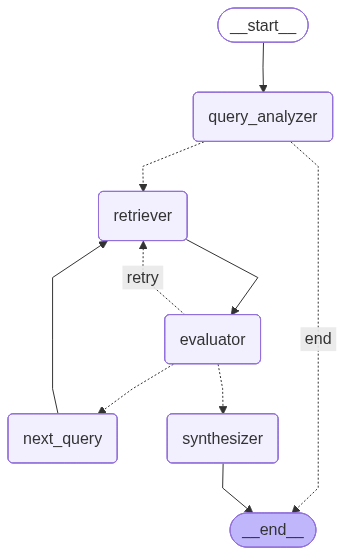

In [23]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))


## Initial State Helper

Όλα τα πεδία πρέπει να αρχικοποιηθούν — ακόμα και αν είναι άδεια.


In [24]:
def make_initial_state(question: str) -> AgentState:
    return {
        "question":      question,
        "query_type":    "",
        "queries":       [],
        "current_query": "",
        "retry_count":   0,
        "chunks":        [],
        "all_chunks":    [],
        "query_idx":     0,
        "sufficient":    False,
        "score":         0,
        "answer":        "",
    }

def ask(question: str) -> str:
    """Εκτελεί το full pipeline και επιστρέφει την απάντηση."""
    result = app.invoke(make_initial_state(question))
    return result["answer"]


## Σενάριο 1: Απλή Ερώτηση

Αναμενόμενη ροή: `query_analyzer`  `retriever`  `evaluator`  `synthesizer`  `END`


In [25]:
print("\n" + "#" * 70)
print("ΣΕΝΑΡΙΟ 1: Απλή ερώτηση")
print("#" * 70)

answer1 = ask("How do Transformers work?")

print("\n" + "─" * 70)
print("ΤΕΛΙΚΗ ΑΠΑΝΤΗΣΗ:")
print(answer1)



######################################################################
ΣΕΝΑΡΙΟ 1: Απλή ερώτηση
######################################################################

[QueryAnalyzer] Q: How do Transformers work?
[QueryAnalyzer] raw: {"type": "simple", "queries": ["Transformer architecture", "self-attention mechanism"]}
[QueryAnalyzer] type=simple, queries=['Transformer architecture', 'self-attention mechanism']

[Retriever] attempt 1, query: 'Transformer architecture'
[Retriever] got 5 chunks (top score: 0.6351)
[Evaluator] score=3/5, sufficient=True, reason: Passage [1] discusses the Transformer architecture's global modeling capability and its limitations, while Passage [2] explores the effect of pretraining on architectural abilities, which is related to Transformers.
[NextQuery] Moving to sub-query 2/2: 'self-attention mechanism'

[Retriever] attempt 1, query: 'self-attention mechanism'
[Retriever] got 5 chunks (top score: 0.6574)
[Evaluator] score=4/5, sufficient=True, reason: Pa

## Σενάριο 2: Σύνθετη Ερώτηση (Query Decomposition)

Αναμενόμενη ροή: `query_analyzer`  `retriever`  `evaluator`  `next_query`  `retriever`  `evaluator`  `synthesizer`  `END`


In [26]:
print("\n" + "#" * 70)
print("ΣΕΝΑΡΙΟ 2: Σύνθετη ερώτηση — query decomposition")
print("#" * 70)

answer2 = ask(
    "Compare the energy efficiency and language modeling performance "
    "of Recurrent neural networks versus transformer-based models"
)

print("\n" + "─" * 70)
print("ΤΕΛΙΚΗ ΑΠΑΝΤΗΣΗ:")
print(answer2)



######################################################################
ΣΕΝΑΡΙΟ 2: Σύνθετη ερώτηση — query decomposition
######################################################################

[QueryAnalyzer] Q: Compare the energy efficiency and language modeling performance of Recurrent neural networks versus transformer-based models
[QueryAnalyzer] raw: {"type": "complex", "queries": ["Recurrent neural network vs transformer", "energy efficiency comparison", "language modeling performance comparison"]}
[QueryAnalyzer] type=complex, queries=['Recurrent neural network vs transformer', 'energy efficiency comparison', 'language modeling performance comparison']

[Retriever] attempt 1, query: 'Recurrent neural network vs transformer'
[Retriever] got 5 chunks (top score: 0.67)
[Evaluator] score=4/5, sufficient=False, reason: Passage does not directly compare recurrent neural networks (RNNs) to transformer models.

[Retriever] attempt 2, query: 'Recurrent neural network vs transformer: how 

## Σενάριο 3: Ερώτηση εκτός πεδίου

Αναμενόμενη ροή: `query_analyzer`  `END` (early exit)


In [27]:
print("\n" + "#" * 70)
print("ΣΕΝΑΡΙΟ 3: Ερώτηση εκτός πεδίου")
print("#" * 70)

answer3 = ask("What is the recipe for traditional Greek moussaka?")

print("\n" + "─" * 70)
print("ΤΕΛΙΚΗ ΑΠΑΝΤΗΣΗ:")
print(answer3)



######################################################################
ΣΕΝΑΡΙΟ 3: Ερώτηση εκτός πεδίου
######################################################################

[QueryAnalyzer] Q: What is the recipe for traditional Greek moussaka?
[QueryAnalyzer] raw: {"type": "out_of_scope", "queries": [], "reason": "Culinary recipe, not AI/ML research."}
[QueryAnalyzer] type=out_of_scope, queries=[]

──────────────────────────────────────────────────────────────────────
ΤΕΛΙΚΗ ΑΠΑΝΤΗΣΗ:
Εκτός πεδίου: Culinary recipe, not AI/ML research.


## Σενάριο 4: Ερώτηση που θα πυροδοτήσει το retry loop

Χρησιμοποιούμε query για θέμα που είναι σχετικό αλλά υπο-εκπροσωπούμενο στο corpus,
ώστε ο evaluator να επιστρέψει χαμηλό score και να ξεκινήσει το retry loop.


In [28]:
print("\n" + "#" * 70)
print("ΣΕΝΑΡΙΟ 4: Retry loop (query με χαμηλό retrieval quality)")
print("#" * 70)

# Επιλέξτε ένα query που είναι σχετικό αλλά πιθανώς δύσκολο να απαντηθεί
answer4 = ask("What specific hardware implementations exist for running spiking neural networks efficiently?")

print("\n" + "─" * 70)
print("ΤΕΛΙΚΗ ΑΠΑΝΤΗΣΗ:")
print(answer4)



######################################################################
ΣΕΝΑΡΙΟ 4: Retry loop (query με χαμηλό retrieval quality)
######################################################################

[QueryAnalyzer] Q: What specific hardware implementations exist for running spiking neural networks efficiently?
[QueryAnalyzer] raw: {"type": "simple", "queries": ["spiking neural network hardware implementation"]}
[QueryAnalyzer] type=simple, queries=['spiking neural network hardware implementation']

[Retriever] attempt 1, query: 'spiking neural network hardware implementation'
[Retriever] got 5 chunks (top score: 0.5247)
[Evaluator] score=2/5, sufficient=False, reason: Passage does not specifically discuss spiking neural network hardware implementation

[Retriever] attempt 2, query: 'spiking brain-inspired large models or AI ASICs for machine learning'
[Retriever] got 5 chunks (top score: 0.674)
[Evaluator] score=3/5, sufficient=False, reason: Passage [1] discusses Spikingbrain: Spik

## Interactive Mode

Δοκιμάστε τις δικές σας ερωτήσεις.


In [29]:
my_question = "What training techniques are used to improve spiking neural networks for NLP?"

print(f"Q: {my_question}\n")
print("=" * 70)
print(ask(my_question))


Q: What training techniques are used to improve spiking neural networks for NLP?


[QueryAnalyzer] Q: What training techniques are used to improve spiking neural networks for NLP?
[QueryAnalyzer] raw: {"type": "simple", "queries": ["spiking neural networks NLP training techniques"]}
[QueryAnalyzer] type=simple, queries=['spiking neural networks NLP training techniques']

[Retriever] attempt 1, query: 'spiking neural networks NLP training techniques'
[Retriever] got 5 chunks (top score: 0.5367)
[Evaluator] score=2/5, sufficient=False, reason: None of the passages directly discuss spiking neural networks NLP training techniques.

[Retriever] attempt 2, query: 'spiking neural networks NLP training techniques'
[Retriever] got 5 chunks (top score: 0.5367)
[Evaluator] score=2/5, sufficient=False, reason: None of the passages directly discuss spiking neural networks for NLP training techniques.

[Retriever] attempt 3, query: 'spiking neural networks in natural language processing'
[Retriever]

## Streaming: Παρακολουθώντας κάθε βήμα

Το LangGraph υποστηρίζει streaming: βλέπουμε κάθε node step-by-step.
Χρήσιμο για debugging και για το demo video.


In [30]:
stream_question = "How are spiking neural networks trained using surrogate gradients?"

print(f"Streaming execution for: '{stream_question}'\n")
print("=" * 70)

for step in app.stream(make_initial_state(stream_question)):
    node_name = list(step.keys())[0]
    node_output = step[node_name]
    print(f"\n NODE: {node_name}")
    # Εκτύπωσε μόνο τα πεδία που άλλαξαν
    for k, v in node_output.items():
        if v and k not in ("chunks", "all_chunks"):  # skip large lists
            print(f"  {k}: {str(v)[:100]}")

print("\n" + "=" * 70)
print("Streaming complete.")


Streaming execution for: 'How are spiking neural networks trained using surrogate gradients?'


[QueryAnalyzer] Q: How are spiking neural networks trained using surrogate gradients?
[QueryAnalyzer] raw: {"type": "complex", "queries": ["spiking neural network training", "surrogate gradients optimization"]}
[QueryAnalyzer] type=complex, queries=['spiking neural network training', 'surrogate gradients optimization']

 NODE: query_analyzer
  query_type: complex
  queries: ['spiking neural network training', 'surrogate gradients optimization']
  current_query: spiking neural network training

[Retriever] attempt 1, query: 'spiking neural network training'
[Retriever] got 5 chunks (top score: 0.5741)

 NODE: retriever
[Evaluator] score=4/5, sufficient=True, reason: Passage [1] discusses spiking neural network training, specifically the Spikingbrain model.

 NODE: evaluator
  score: 4
  sufficient: True
  retry_count: 1
  current_query: spiking neural network training
[NextQuery] Moving to su

## Σύνοψη

### Τι υλοποιήσαμε

| Στοιχείο | Υλοποίηση |
|---|---|
| **Query Analyzer** | LLM με structured JSON output, 3 κατηγορίες |
| **Retriever** | ChromaDB vector search με all-MiniLM-L6-v2 embeddings |
| **Evaluator** | LLM με 1-5 score + reformulation |
| **Synthesizer** | LLM με inline citations + no-hallucination constraint |
| **ReAct Loop** | Conditional edge: retry -> retriever (max 3) |
| **Query Decomposition** | next_query node για complex queries |
| **Early Exit** | out_of_scope ->  END χωρίς retrieval |

### Για την εργασία σας

Ξεκινήστε από αυτό το σύστημα και:
1. **Αλλάξτε το corpus**: χρησιμοποιήστε το δικό σας θέμα και API
2. **Προσαρμόστε τα prompts**: αναφερθείτε στο δικό σας θεματικό domain
3. **Πειραματιστείτε με parameters**: `TOP_K`, `MAX_RETRIES`, `SCORE_THRESHOLD`, chunk size
4. **Αξιολογήστε με 10+ ερωτήσεις**: simple / complex / out-of-scope
5. **Καταγράψτε τα αποτελέσματα** για το report σας
